# Plant Classification Model

This project builds a simple image classification model designed to identify a small set of common household plants from photos. The model is based on EfficientNetB0 using transfer learning, with the pre-trained layers initially frozen and lightly fine-tuned for this specific task.

The idea is to create a foundation for an application (streamlit) where a user can upload an image of a plant and receive identification along with useful tips and information on care guidance.

## Imports & Data Loading

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pathlib

In [2]:
import cv2
import warnings
warnings.filterwarnings("ignore", category = DeprecationWarning)
import imghdr

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import sys, os

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("CWD:", os.getcwd())


Python executable: /Users/iberis/Projects/nod_bootcamp/Python/.venv/bin/python
Python version: 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
CWD: /Users/iberis/Projects/nod_bootcamp/Py_projects/deep_plant_project


In [ ]:
# Images are loaded from the folder, labels are assigned based on subfolders, and prepared as batches for training.

tf.keras.utils.image_dataset_from_directory

Signature:
tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format='tf',
    verbose=True,
)
Source:   
@keras_export(
    [
        "keras.utils.image_dataset_from_directory",
        "keras.preprocessing.image_dataset_from_directory",
    ]
)
def image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_fo

In [ ]:
# Setting image and batch sizes and data location

DATA_DIR = "plants_data"
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
# data = tf.keras.utils.image_dataset_from_directory("plant_images")

## ML Pipeline setup

### Dataset Preparation & Validation

In [ ]:
# Load images, resize them, and split into training and validation datasets

data_dir = pathlib.Path(DATA_DIR)

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed = SEED,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = SEED,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE,
)

Found 2633 files belonging to 15 classes.
Using 2107 files for training.
Found 2633 files belonging to 15 classes.
Using 526 files for validation.


In [ ]:
# Check that the detected class names match the expected plant categories (it does)

class_names = train_ds.class_names
print(class_names)
len(class_names)

['alocasia', 'aloe', 'areca palm', 'calathea', 'clorophytum', 'crassula', 'diefenbachia', 'dracaena', 'ficus lyrata', 'monstera', 'pilea', 'pothos', 'sansevieria', 'schefflera', 'zamioculcas']


15

In [ ]:
# Creating a batch

batch = next(train_ds.as_numpy_iterator())
images, labels = batch

print("Images shape:", images.shape)   # (batch_size, 224, 224, 3)
print("Labels shape:", labels.shape)   # (batch_size)
print("First 5 labels (indices):", labels[:5])
print("Class names:", class_names)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
First 5 labels (indices): [ 7  8  6 10  3]
Class names: ['alocasia', 'aloe', 'areca palm', 'calathea', 'clorophytum', 'crassula', 'diefenbachia', 'dracaena', 'ficus lyrata', 'monstera', 'pilea', 'pothos', 'sansevieria', 'schefflera', 'zamioculcas']


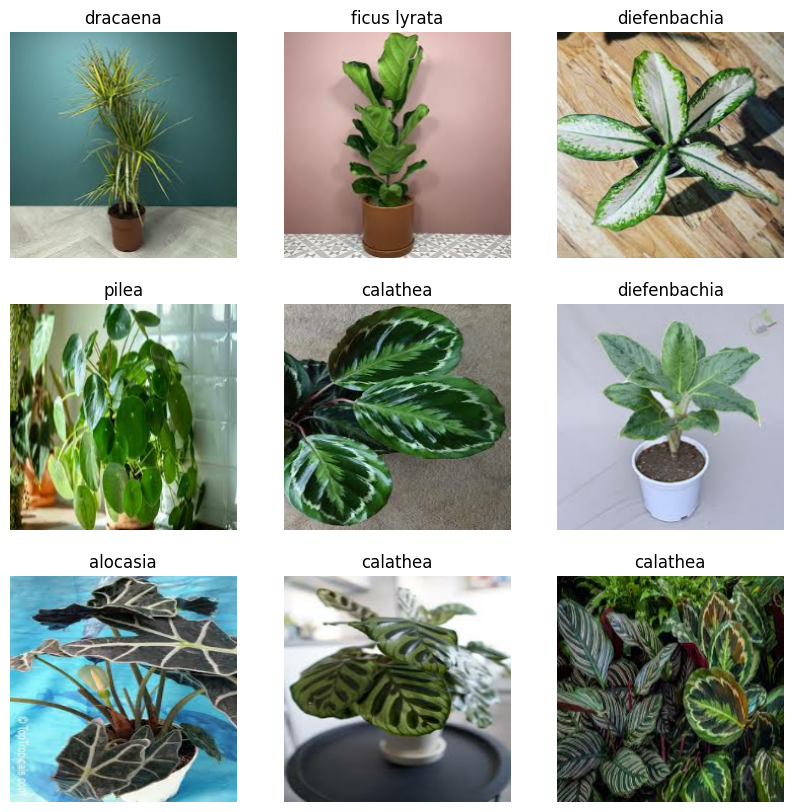

In [13]:
# Plotting some images to see if it's all working properly

plt.figure(figsize =(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [14]:
# Autotuning to prepare the next batches in the background while the model is training on the current batch. 
# This eliminates stalling.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [15]:
# Data augmentation to make the model more robust

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name = "data_augmentation"
)

In [ ]:
IMG_SIZE = 224  # same as before
class_names = train_ds.class_names
num_classes = len(class_names)

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights="imagenet"
)

base_model.trainable = False  # start with frozen base


### Building the model using pretrained EfficientNetB0 as backbone and adding a classifier on top.

In [ ]:
IMG_SIZE = 224  # same as before
class_names = train_ds.class_names
num_classes = len(class_names)

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights="imagenet"
)

base_model.trainable = False  # start with frozen base


In [17]:
IMG_SIZE = 224  # not changing the image size, it's still the same as before
num_classes = len(class_names)

base_model = keras.applications.EfficientNetB0(
    include_top = False,
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    weights = "imagenet"
)

base_model.trainable = False # freezing the base for now

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Wrapping the base model into a full model

inputs = keras.Input(shape = (IMG_SIZE, IMG_SIZE, 3))

# Preprocessing the inputs the same way EfficientNet expects
x = keras.applications.efficientnet.preprocess_input(inputs)

# Applying augmentation
x = data_augmentation(x)

# Pass through base model
x = base_model(x, training = False)

# Pool + dense head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation = "softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### Compiling the model

In [19]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
)

In [21]:
# Training the model and fetching history, starting with 15 to test
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = EPOCHS,
)

Epoch 1/15


2025-12-10 10:12:48.289852: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 229ms/step - accuracy: 0.3033 - loss: 2.2147 - val_accuracy: 0.5171 - val_loss: 1.6490
Epoch 2/15


2025-12-10 10:13:04.124251: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 228ms/step - accuracy: 0.5539 - loss: 1.5169 - val_accuracy: 0.6293 - val_loss: 1.2981
Epoch 3/15


...

66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 249ms/step - accuracy: 0.8481 - loss: 0.5895 - val_accuracy: 0.7985 - val_loss: 0.6707
Epoch 14/15


2025-12-10 10:16:23.570179: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 250ms/step - accuracy: 0.8567 - loss: 0.5489 - val_accuracy: 0.7909 - val_loss: 0.6719
Epoch 15/15


2025-12-10 10:16:40.729226: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.8567 - loss: 0.5438 - val_accuracy: 0.7966 - val_loss: 0.6535


In [23]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

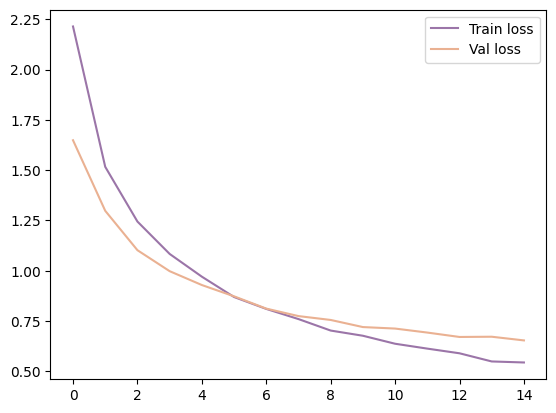

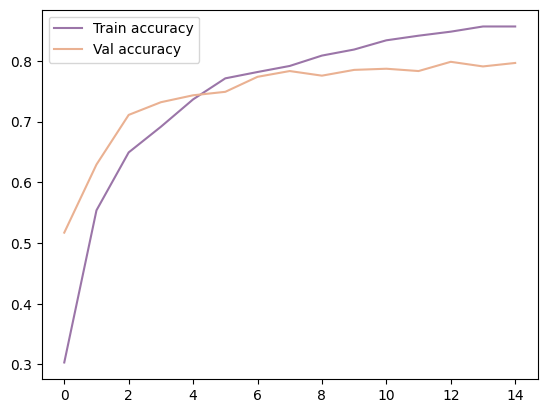

In [22]:
# Plot the learning curve of the model

plt.figure()
plt.plot(history.history["loss"], label = "Train loss", color = "#9B75A8")
plt.plot(history.history["val_loss"], label = "Val loss", color = "#EAB192")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label = "Train accuracy", color = "#9B75A8")
plt.plot(history.history["val_accuracy"], label = "Val accuracy", color = "#EAB192")
plt.legend()
plt.show()

In [32]:
# Saving plot data into csv files for nicer graphs in canva

import pandas as pd

loss_df = pd.DataFrame({
    "epoch": range(1, len(history.history["loss"]) + 1),
    "train_loss": history.history["loss"],
    "val_loss": history.history["val_loss"]
})

loss_df.to_csv("loss_history.csv", index=False)

In [33]:
acc_df = pd.DataFrame({
    "epoch": range(1, len(history.history["accuracy"]) + 1),
    "train_accuracy": history.history["accuracy"],
    "val_accuracy": history.history["val_accuracy"]
})

acc_df.to_csv("accuracy_history.csv", index=False)

### Some fine tuning of the model

In [24]:
# Unfreeze only a small portion of the base model to avoid overfitting, making it slow and cause instability of training
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

# Smaller learning rate
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-5),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
)
fine_tune_epochs = 5
total_epochs = 15 + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=15,   # continue from where we left off with initial 15 epochs
)

Epoch 16/20


2025-12-10 10:30:22.774923: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 302ms/step - accuracy: 0.7299 - loss: 0.9896 - val_accuracy: 0.8023 - val_loss: 0.6434
Epoch 17/20


2025-12-10 10:30:43.331283: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 304ms/step - accuracy: 0.7651 - loss: 0.9080 - val_accuracy: 0.7928 - val_loss: 0.6838
Epoch 18/20


...

66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 317ms/step - accuracy: 0.7798 - loss: 0.8306 - val_accuracy: 0.8023 - val_loss: 0.6947
Epoch 19/20


2025-12-10 10:31:25.539655: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 321ms/step - accuracy: 0.8121 - loss: 0.7609 - val_accuracy: 0.8099 - val_loss: 0.6888
Epoch 20/20


2025-12-10 10:31:47.471023: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 314ms/step - accuracy: 0.8125 - loss: 0.7252 - val_accuracy: 0.8156 - val_loss: 0.6721


In [25]:
# Saving the model and class names

model.save("plant_classifier_effb0_v1.keras")

import json
with open("plant_class_names.json", "w") as f:
    json.dump(class_names, f)

In [26]:
# Load the trained model 
model = keras.models.load_model("plant_classifier_effb0_v1.keras")

#Load class names 
with open("plant_class_names.json", "r") as f:
    class_names = json.load(f)

IMG_SIZE = 224  # should be the same as training size

In [ ]:
# Writing a function that reads an image from a path and converts BGR into RGB, applies EfficientNet’s preprocess_input 
# and adds adds batch dimension

def preprocess_image_cv2(img_path, img_size=224):
    # Read image with cv2 (BGR format)
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")
    
    # Convert BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to model input size
    img = cv2.resize(img, (img_size, img_size))

    # Convert to float32
    img = img.astype("float32")

    # Apply same preprocessing as in training (EfficientNet)
    img = keras.applications.efficientnet.preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    return img

In [ ]:
# This function calls the preprocessor, runs model.predict, sorts probabilities and returns a list of 
# the plant name and probability in pairs

def predict_plant(img_path, model, class_names, top_k=3):
    # 1. Preprocess the image
    img = preprocess_image_cv2(img_path, img_size=IMG_SIZE)

    # 2. Run model prediction
    preds = model.predict(img)[0] 
    top_indices = preds.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        plant_name = class_names[idx]
        confidence = float(preds[idx])
        results.append((plant_name, confidence))

    return results

## Model Testing

 **Real-world testing (out-of-sample images)**:
When tested on photos taken outside the training dataset (different lighting/angles/plant condition), predictions were inconsistent. The model performed best on clear, front-facing images and struggled with unusual angles or less “typical” plant appearances. This suggests the model is sensitive to dataset bias and would benefit from more diverse training images and stronger augmentation.

### Test no1!

In [ ]:
# Testing the model with my own picture of a very poor, unhealthy looking Monstera

test_path = "test_images/dying_monstera.jpeg"
results = predict_plant(test_path, model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step


In [31]:
for name, prob in results:
    print(f"{name}: {prob * 100:.2f}%")

pothos: 28.64%
alocasia: 20.11%
diefenbachia: 19.03%


### Test no2!
- Healthy Monstera image

In [35]:
test_path = "test_images/my_monstera1.jpeg"
results = predict_plant(test_path, model, class_names)

for name, prob in results:
    print(f"{name}: {prob * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
monstera: 80.12%
alocasia: 6.28%
zamioculcas: 3.51%


### Test no3!
- Healthy Monstera image

In [43]:
test_path = "test_images/my_monstera2.jpeg"
results = predict_plant(test_path, model, class_names)

for name, prob in results:
    print(f"{name}: {prob * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
zamioculcas: 50.04%
monstera: 20.06%
alocasia: 5.10%


### Test no4!
- Healthy Monstera image

In [37]:
test_path = "test_images/my_monstera3.jpeg"
results = predict_plant(test_path, model, class_names)

for name, prob in results:
    print(f"{name}: {prob * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
alocasia: 27.84%
zamioculcas: 24.20%
monstera: 20.87%


### Test no5!
- Healthy Areca palm image

In [40]:
test_path = "test_images/my_palm1.jpeg"
results = predict_plant(test_path, model, class_names)

for name, prob in results:
    print(f"{name}: {prob * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
zamioculcas: 24.92%
dracaena: 16.71%
monstera: 16.32%


### Test no6!
- Healthy Areca palm image

In [41]:
test_path = "test_images/my_palm2.jpeg"
results = predict_plant(test_path, model, class_names)

for name, prob in results:
    print(f"{name}: {prob * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
zamioculcas: 85.72%
alocasia: 7.56%
areca palm: 1.65%


### Test no7!
- Healthy Areca palm image

In [42]:
test_path = "test_images/my_palm3.jpeg"
results = predict_plant(test_path, model, class_names)

for name, prob in results:
    print(f"{name}: {prob * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
areca palm: 41.28%
dracaena: 19.58%
zamioculcas: 16.43%


## Conclusion

This project demonstrates a working prototype for classifying a small set of common household plants using transfer learning with EfficientNetB0. The model performs well on validation data and achieves reasonably strong accuracy on clear, well-framed images.

However, testing on new, real-world photos revealed inconsistent predictions, particularly when plants were photographed from unusual angles, under different lighting conditions, or when their appearance deviated from typical training examples. This highlights the model’s sensitivity to dataset size and diversity.

Overall, the project successfully establishes a functional baseline and demonstrates the feasibility of building a plant identification system. Future improvements would focus on expanding and diversifying the dataset, applying stronger data augmentation, and further fine-tuning to improve generalization to real-world images.